In [2]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Connect to the database
DB_PATH = 'global.db'
conn = sqlite3.connect(DB_PATH)
print(f"Connected to {DB_PATH}")

Connected to global.db


In [3]:
# Get top N=4 most prolific users
N = 4

top_users_query = f"""
SELECT username, COUNT(*) as combo_count
FROM combinations
GROUP BY username
ORDER BY combo_count DESC
LIMIT {N}
"""
top_users_df = pd.read_sql_query(top_users_query, conn)
top_users = top_users_df['username'].tolist()

print(f"Top {N} most prolific users:")
display(top_users_df)

Top 4 most prolific users:


,username,combo_count
0,isabel,4916
1,tim,2179
2,ace,1378
3,izzy,1191


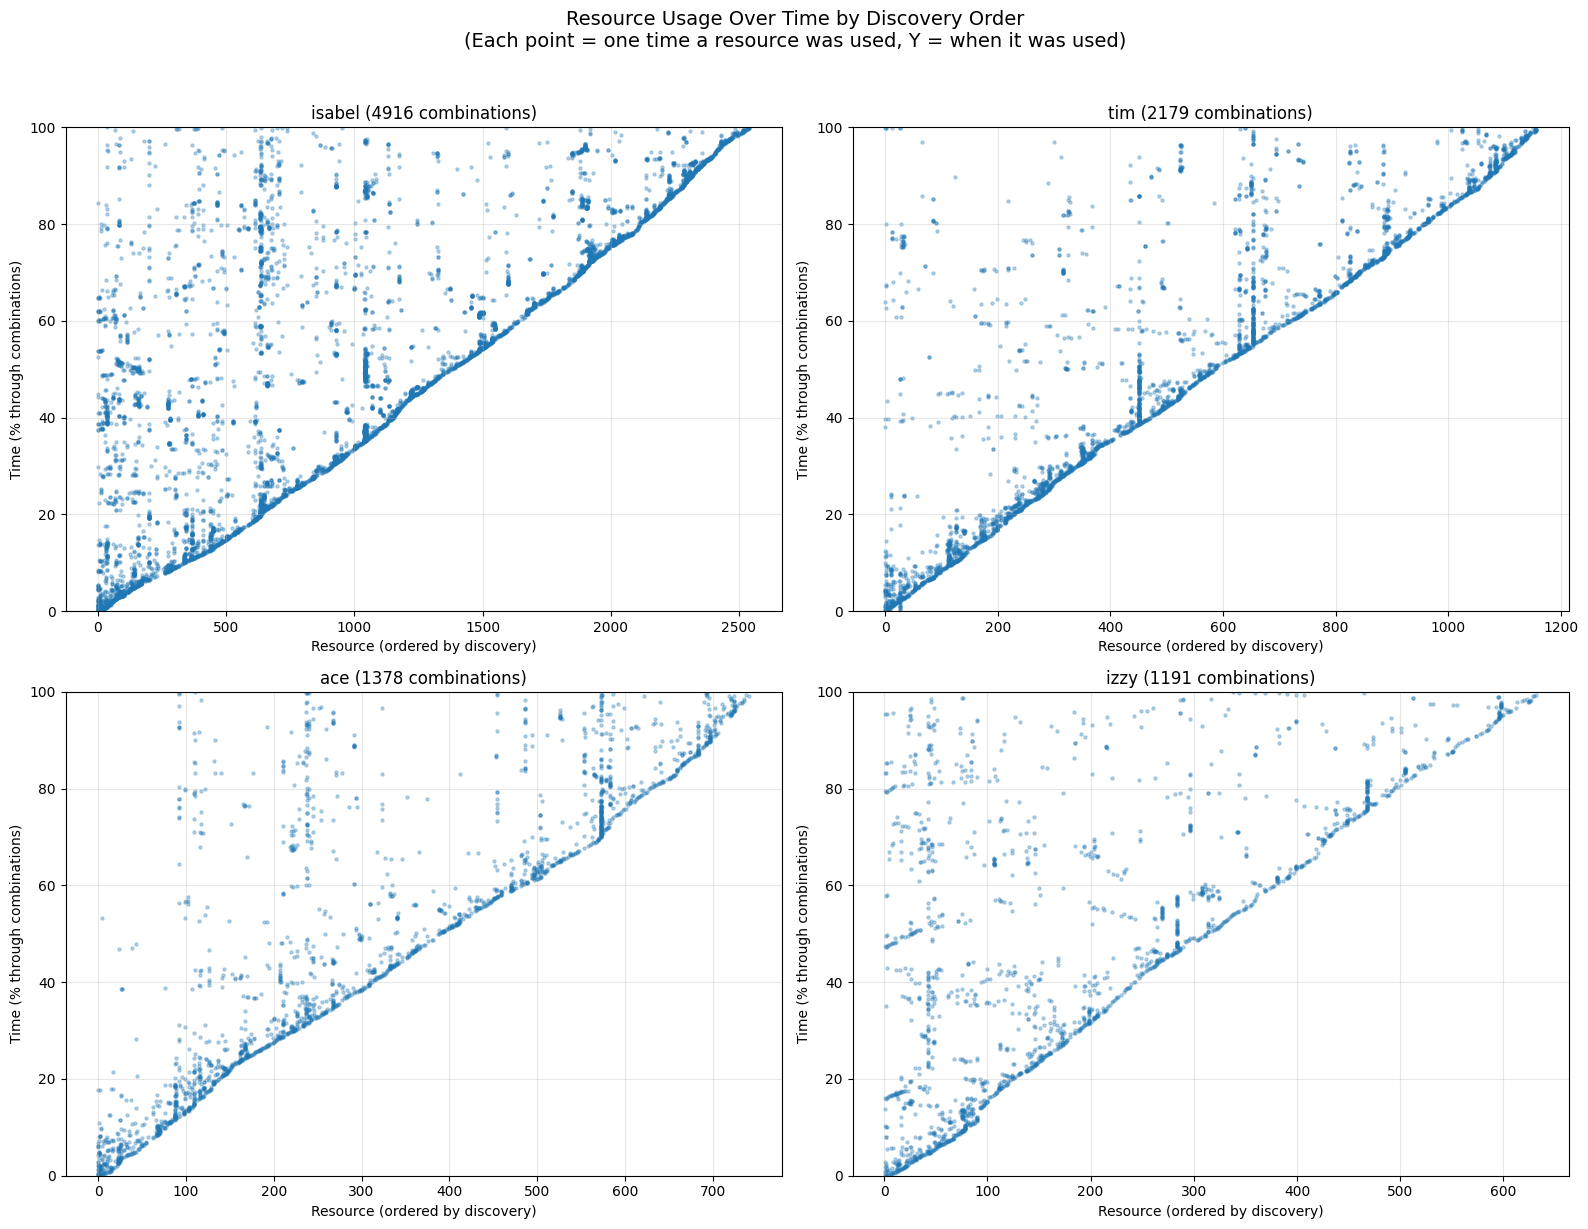

In [5]:
# For each top user, create a scatterplot:
# X-axis: resources ordered by discovery order (when the user first discovered them)
# Y-axis: when in time (as % of total combinations) the word was used

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, username in enumerate(top_users):
    ax = axes[idx]
    
    # Get all combinations for this user, ordered by id (chronological)
    user_combos_query = f"""
    SELECT id, firstWord, secondWord, resultName
    FROM combinations
    WHERE username = '{username}'
    ORDER BY id
    """
    user_combos = pd.read_sql_query(user_combos_query, conn)
    total_combos = len(user_combos)
    
    # Track discovery order for each resource
    # A resource is "discovered" when it first appears as a result
    discovery_order = {}  # word -> order index
    discovery_counter = 0
    
    # First pass: determine discovery order based on when results first appear
    for _, row in user_combos.iterrows():
        result = row['resultName']
        if result not in discovery_order:
            discovery_order[result] = discovery_counter
            discovery_counter += 1
    
    # Also track when input words first appear (they might be starting materials)
    # Starting materials (Water, Fire, Earth, Wind) should be at the beginning
    starting_materials = ['Water', 'Fire', 'Earth', 'Wind']
    for mat in starting_materials:
        if mat not in discovery_order:
            # Insert at the beginning by shifting everything
            for word in discovery_order:
                discovery_order[word] += 1
            discovery_order[mat] = 0
            discovery_counter += 1
    
    # Track when each word was used (as % of total combinations)
    # Each time a word is used, record the time position (combo_index / total_combos)
    x_vals = []
    y_vals = []
    
    for combo_idx, (_, row) in enumerate(user_combos.iterrows()):
        time_pct = (combo_idx / total_combos) * 100  # Convert to percentage
        
        for word in [row['firstWord'], row['secondWord']]:
            if word in discovery_order:
                x_vals.append(discovery_order[word])
                y_vals.append(time_pct)
    
    # Create scatter plot
    ax.scatter(x_vals, y_vals, alpha=0.3, s=5)
    ax.set_xlabel('Resource (ordered by discovery)')
    ax.set_ylabel('Time (% through combinations)')
    ax.set_title(f'{username} ({total_combos} combinations)')
    ax.set_ylim(0, 100)
    ax.grid(True, alpha=0.3)

plt.suptitle('Resource Usage Over Time by Discovery Order\n(Each point = one time a resource was used, Y = when it was used)', 
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()